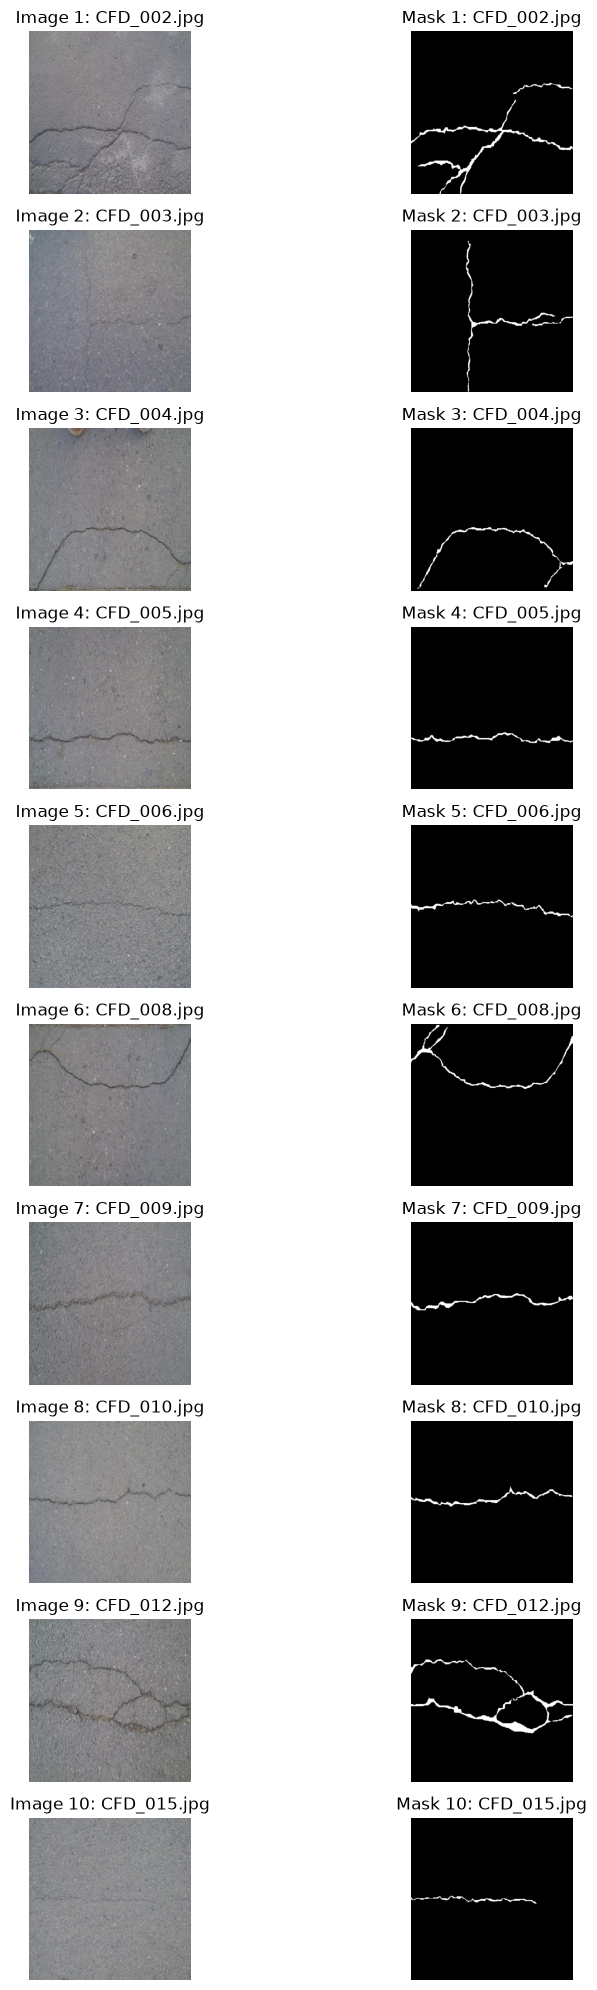

In [11]:
import os
import cv2
import matplotlib.pyplot as plt

# مسارات المجلدات
images_dir = r"C:\Users\PC-LAB1\Desktop\day3\train\images\images"
masks_dir = r"C:\Users\PC-LAB1\Desktop\day3\train\masks\masks"

# الحصول على الصور
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])

# أول 10
selected_images = image_files[:10]

# عرض الصور والـ Masks
plt.figure(figsize=(10, 20))

for i, file in enumerate(selected_images):

    # قراءة Image
    image_path = os.path.join(images_dir, file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # قراءة Mask بنفس اسم الصورة
    mask_path = os.path.join(masks_dir, file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Image
    plt.subplot(10, 2, 2 * i + 1)
    plt.imshow(image)
    plt.title(f"Image {i + 1}: {file}")
    plt.axis("off")

    # Mask
    plt.subplot(10, 2, 2 * i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i + 1}: {file}")
    plt.axis("off")

plt.tight_layout()
plt.show()

C:\Users\PC-LAB1\AppData\Local\Temp\ipykernel_14476\799008174.py:39: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_bool = remove_small_objects(cleaned_bool, min_size=15, connectivity=2)
C:\Users\PC-LAB1\AppData\Local\Temp\ipykernel_14476\799008174.py:137: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


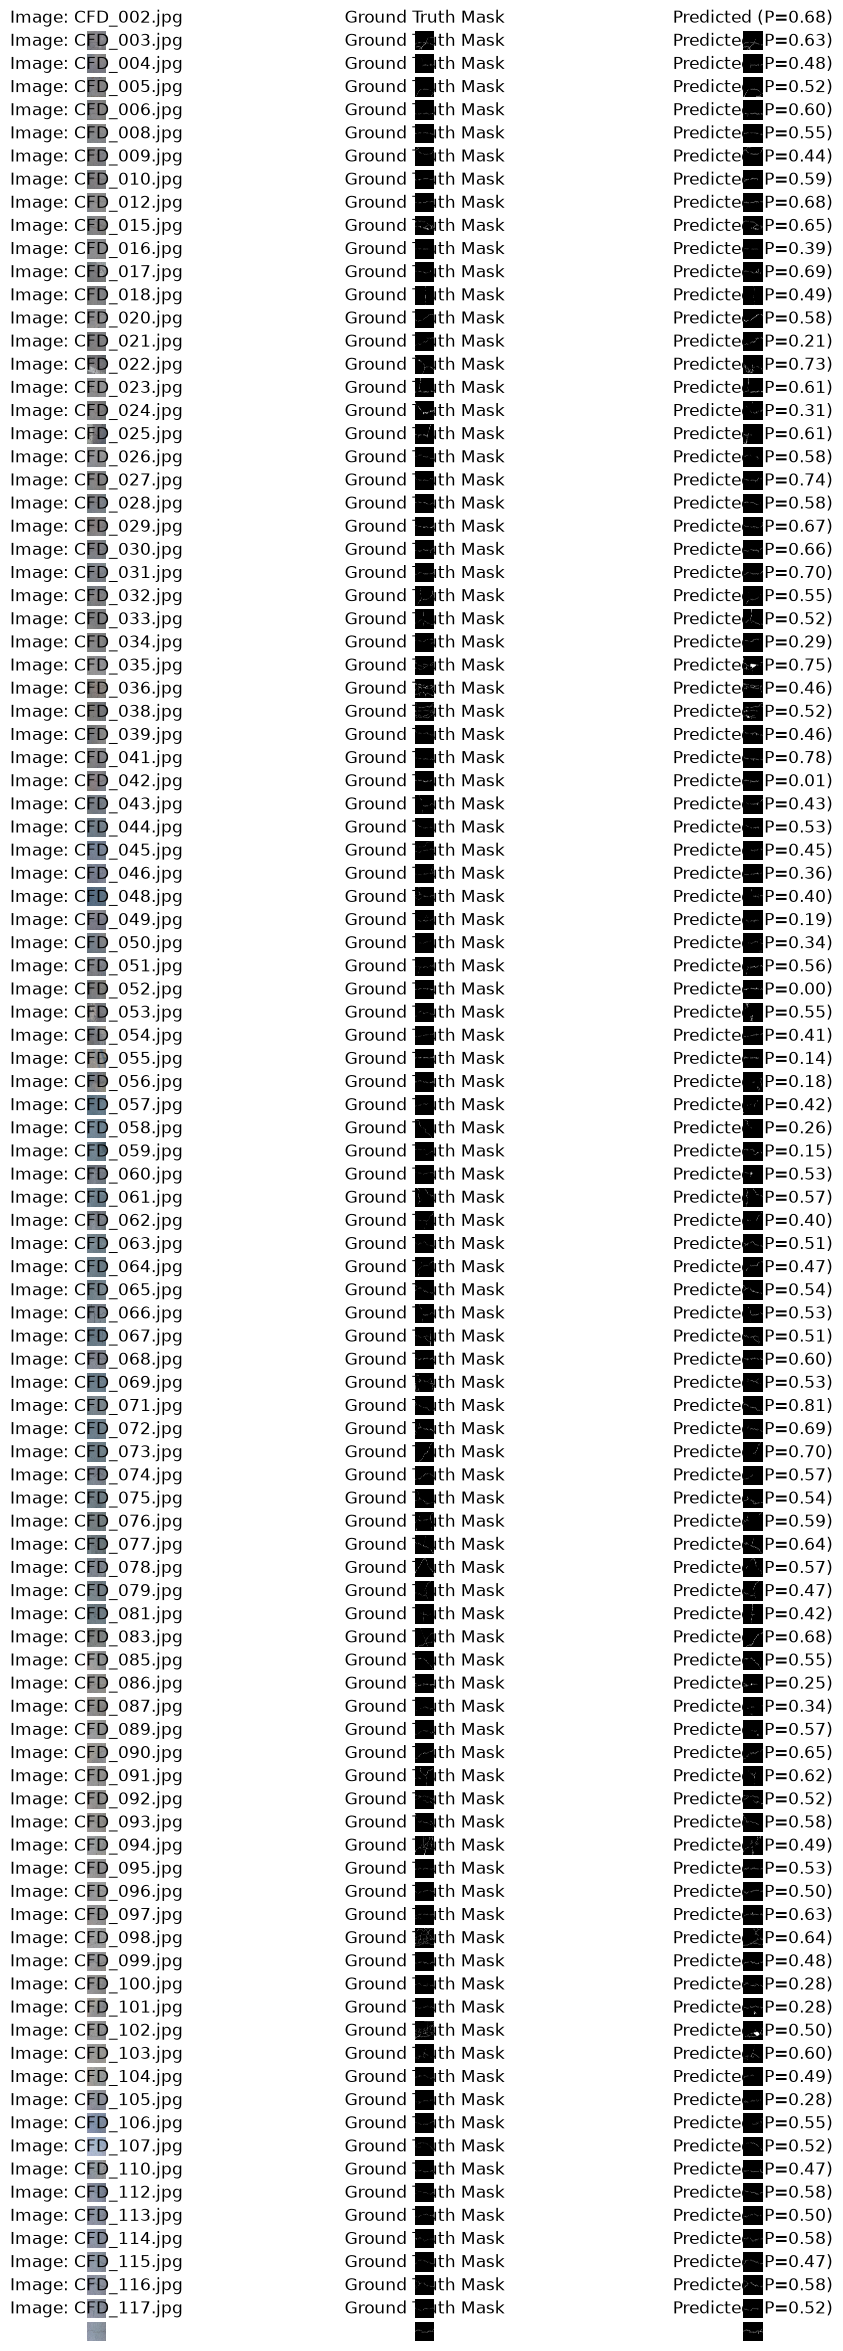

File                       Precision     Recall         F1        IoU
CFD_002.jpg                    0.683      0.672      0.677      0.512
CFD_003.jpg                    0.629      0.433      0.513      0.345
CFD_004.jpg                    0.478      0.914      0.628      0.457
CFD_005.jpg                    0.522      0.947      0.673      0.507
CFD_006.jpg                    0.598      0.685      0.638      0.469
CFD_008.jpg                    0.552      0.806      0.655      0.487
CFD_009.jpg                    0.441      0.558      0.493      0.327
CFD_010.jpg                    0.587      0.902      0.711      0.552
CFD_012.jpg                    0.679      0.540      0.602      0.430
CFD_015.jpg                    0.651      0.557      0.600      0.429
CFD_016.jpg                    0.392      0.764      0.518      0.349
CFD_017.jpg                    0.685      0.798      0.737      0.584
CFD_018.jpg                    0.485      0.972      0.647      0.478
CFD_020.jpg         

In [48]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sato, apply_hysteresis_threshold
from skimage.exposure import equalize_adapthist
from skimage.morphology import remove_small_objects

images_dir = r"C:\Users\PC-LAB1\Desktop\day3\train\images\images"
masks_dir  = r"C:\Users\PC-LAB1\Desktop\day3\train\masks\masks"

image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])
selected_images = image_files[:100]


def segment_crack(gray):
    # 1) تطبيع إضاءة محلي (CLAHE) لتقليل تأثير الظلال/الإضاءة غير المنتظمة
    gray_norm = gray.astype(np.float64) / 255.0
    enhanced = equalize_adapthist(gray_norm, clip_limit=0.01)
    enhanced = cv2.GaussianBlur((enhanced * 255).astype(np.uint8), (3, 3), 0)
    enhanced = enhanced.astype(np.float64) / 255.0

    # 2) Sato ridge filter (متعدد المقاييس) - يكتشف البنى الخيطية الرفيعة
    ridges = sato(enhanced, sigmas=range(1, 5, 1), black_ridges=True)
    ridges_norm = cv2.normalize(ridges, None, 0, 255, cv2.NORM_MINMAX).astype(np.float64)

    # 3) Hysteresis Thresholding: عتبة عالية (بداية مؤكدة) + عتبة منخفضة (امتداد)
    high_val = np.percentile(ridges_norm, 98.5)
    low_val  = np.percentile(ridges_norm, 93)
    binary = apply_hysteresis_threshold(ridges_norm, low_val, high_val)
    binary = (binary.astype(np.uint8)) * 255

    # 4) إغلاق خفيف لربط الفجوات الصغيرة
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=1)

    # 5) إزالة الكائنات الصغيرة جدًا (ضوضاء نقطية)
    cleaned_bool = cleaned > 0
    cleaned_bool = remove_small_objects(cleaned_bool, min_size=15, connectivity=2)
    cleaned = (cleaned_bool.astype(np.uint8)) * 255

    # 6) فلترة بالشكل: استطالة (elongation) أو طول كافٍ
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    comp_info = []  # (mask, length, area) لكل مكوّن ناجح

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 8:
            continue
        rect = cv2.minAreaRect(cnt)
        (rw, rh) = rect[1]
        if rw == 0 or rh == 0:
            continue
        elongation = max(rw, rh) / (min(rw, rh) + 1e-6)
        length = max(rw, rh)

        if elongation >= 2.8 or length >= 18:
            comp_mask = np.zeros_like(cleaned)
            cv2.drawContours(comp_mask, [cnt], -1, 255, thickness=cv2.FILLED)
            comp_info.append((comp_mask, length, area))

    if len(comp_info) == 0:
        return np.zeros_like(cleaned)

    # 7) ===== تحديد الـ Core: أكبر مكوّن مطلقًا + أي مكوّن مقارب له في الحجم =====
    comp_info.sort(key=lambda x: -x[2])  # ترتيب تنازلي بالمساحة
    core_mask = comp_info[0][0].copy()
    core_area = comp_info[0][2]

    for comp_mask, length, area in comp_info[1:]:
        if area >= 0.4 * core_area:  # مكوّن كبير بشكل مقارب = غالبًا جزء من نفس الشق
            core_mask = cv2.bitwise_or(core_mask, comp_mask)

    # 8) ===== Distance Transform: قياس دقيق للقرب بدل dilation ثابت =====
    core_inv = cv2.bitwise_not(core_mask)
    dist_from_core = cv2.distanceTransform(core_inv, cv2.DIST_L2, 5)

    max_gap_distance = 15  # أقصى مسافة (بكسل) للاعتبار "امتداد طبيعي" للشق

    final = core_mask.copy()
    for comp_mask, length, area in comp_info[1:]:
        comp_bool = comp_mask > 0
        min_dist_to_core = dist_from_core[comp_bool].min()
        if min_dist_to_core <= max_gap_distance:
            final = cv2.bitwise_or(final, comp_mask)
        # المكونات البعيدة عن الـ core تُستبعد تلقائيًا (ضوضاء)

    return final


def compute_metrics(pred, gt):
    pred_bin = (pred > 127).astype(np.uint8)
    gt_bin   = (gt   > 127).astype(np.uint8)

    tp = np.sum((pred_bin == 1) & (gt_bin == 1))
    fp = np.sum((pred_bin == 1) & (gt_bin == 0))
    fn = np.sum((pred_bin == 0) & (gt_bin == 1))

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    iou       = tp / (tp + fp + fn + 1e-6)

    return precision, recall, f1, iou


results = []
plt.figure(figsize=(12, 30))

for i, file in enumerate(selected_images):
    image_path = os.path.join(images_dir, file)
    mask_path  = os.path.join(masks_dir, file)

    image = cv2.imread(image_path)
    gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    pred = segment_crack(gray)
    precision, recall, f1, iou = compute_metrics(pred, mask)
    results.append((file, precision, recall, f1, iou))

    plt.subplot(100, 3, 3 * i + 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Image: {file}")
    plt.axis("off")

    plt.subplot(100, 3, 3 * i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(100, 3, 3 * i + 3)
    plt.imshow(pred, cmap="gray")
    plt.title(f"Predicted (P={precision:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"{'File':25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'IoU':>10s}")
for file, p, r, f1, iou in results:
    print(f"{file:25s} {p:10.3f} {r:10.3f} {f1:10.3f} {iou:10.3f}")

print(f"\nMean Precision: {np.mean([r[1] for r in results]):.3f}")
print(f"Mean Recall:    {np.mean([r[2] for r in results]):.3f}")
print(f"Mean F1:        {np.mean([r[3] for r in results]):.3f}")
print(f"Mean IoU:       {np.mean([r[4] for r in results]):.3f}")

C:\Users\PC-LAB1\AppData\Local\Temp\ipykernel_14476\1094506304.py:52: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = (remove_small_objects(cleaned > 0, min_size=min_size, connectivity=2).astype(np.uint8)) * 255


File                         Prec     Rec      F1     IoU
CFD_002.jpg                 0.409   0.848   0.552   0.381
CFD_003.jpg                 0.521   0.452   0.484   0.320
CFD_004.jpg                 0.298   0.967   0.456   0.295
CFD_005.jpg                 0.367   0.984   0.534   0.364
CFD_006.jpg                 0.494   0.885   0.634   0.465
CFD_008.jpg                 0.415   0.912   0.570   0.399
CFD_009.jpg                 0.373   0.695   0.486   0.321
CFD_010.jpg                 0.451   0.977   0.617   0.446
CFD_012.jpg                 0.566   0.675   0.615   0.444
CFD_015.jpg                 0.460   0.689   0.552   0.381
CFD_016.jpg                 0.309   0.922   0.463   0.301
CFD_017.jpg                 0.508   0.958   0.664   0.497
CFD_018.jpg                 0.377   0.994   0.547   0.376
CFD_020.jpg                 0.454   0.968   0.619   0.448
CFD_021.jpg                 0.253   0.735   0.377   0.232
CFD_022.jpg                 0.583   0.947   0.722   0.564
CFD_023.jpg   

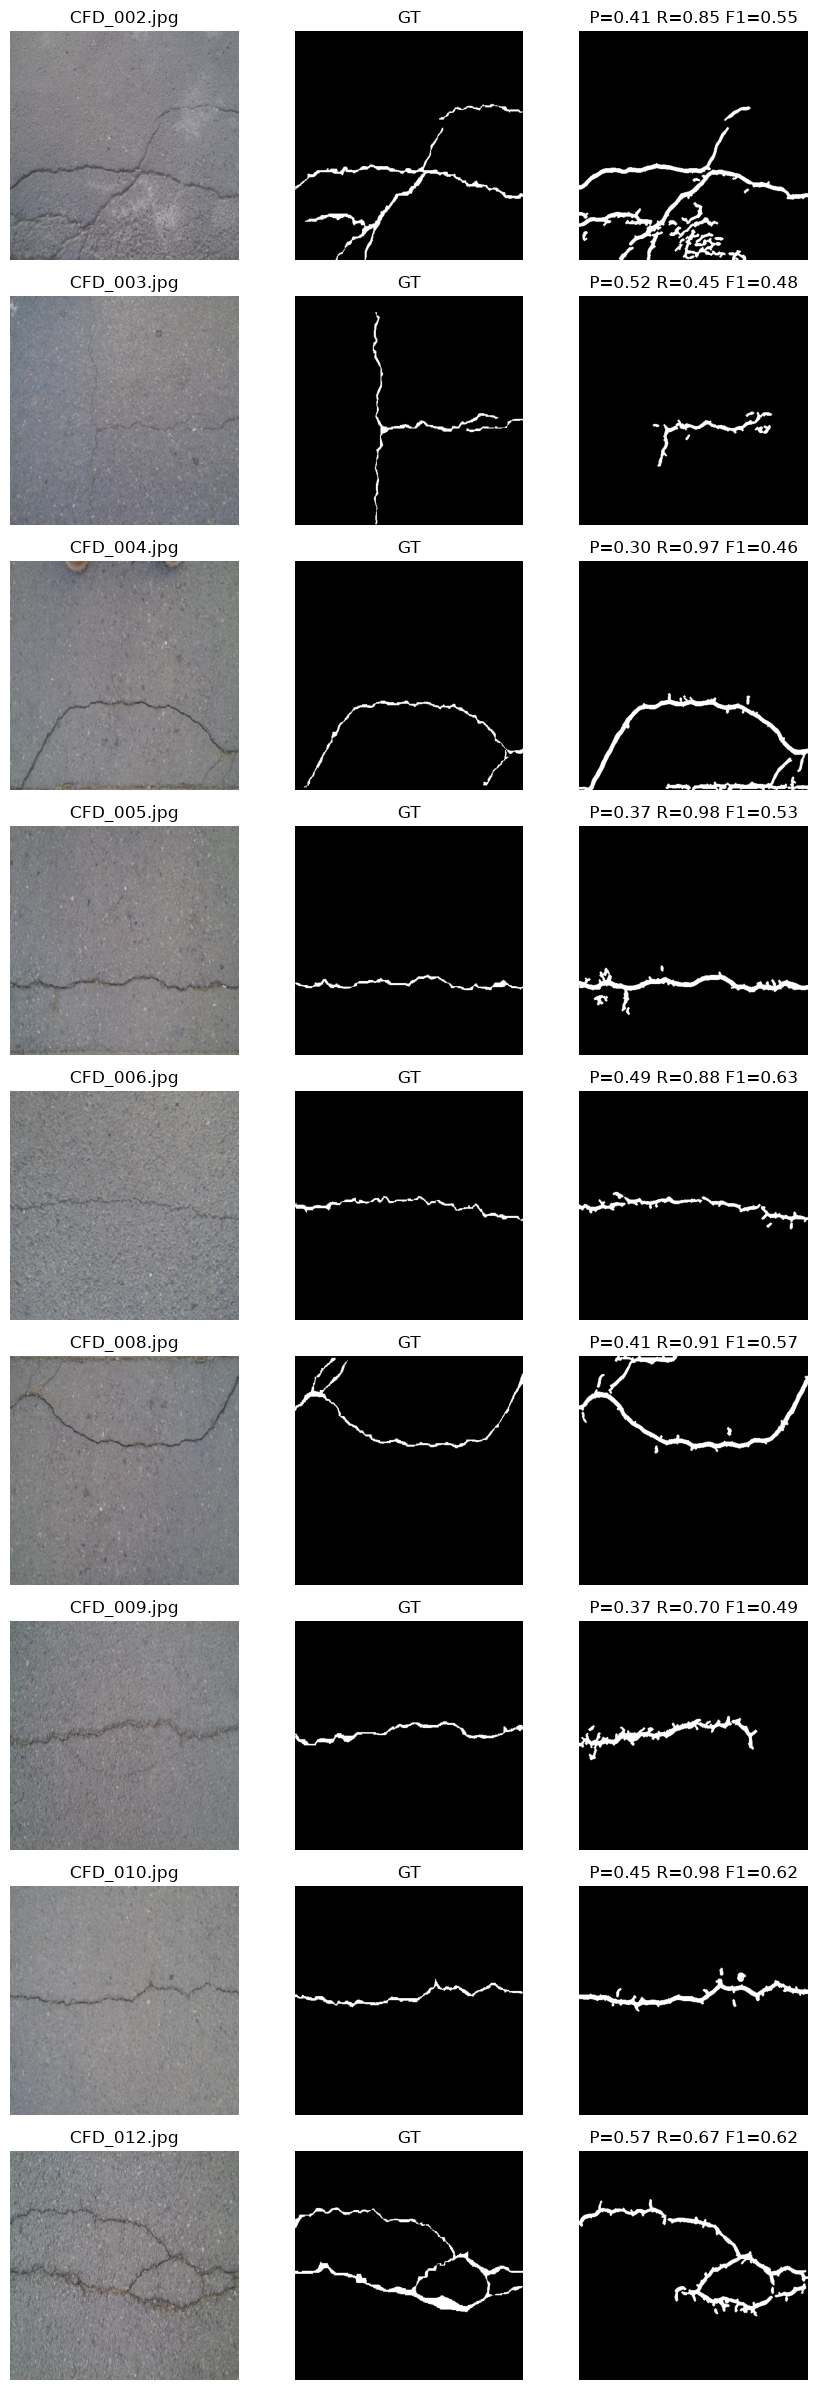

In [47]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.filters import sato, apply_hysteresis_threshold
from skimage.morphology import remove_small_objects

images_dir = r"C:\Users\PC-LAB1\Desktop\day3\train\images\images"
masks_dir  = r"C:\Users\PC-LAB1\Desktop\day3\train\masks\masks"

# ============ 1) دالة التقطيع المحسنة ============
def segment_crack_v2(gray, low_p=90.0, high_p=97.0, dilate_iter=1):
    h, w = gray.shape[:2]
    diag = np.sqrt(h*h + w*w)

    # --- تطبيع إضاءة بـ CLAHE من OpenCV (أسرع من skimage) ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if gray.dtype != np.uint8:
        gray_u8 = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        gray_u8 = gray
    enhanced_u8 = clahe.apply(gray_u8)
    # median يحافظ على الحواف أفضل من Gaussian للشقوق الرفيعة
    enhanced_u8 = cv2.medianBlur(enhanced_u8, 3)
    enhanced = enhanced_u8.astype(np.float64) / 255.0

    # --- Sato متعدد المقاييس (نطاق أوسع للشقوق السميكة والرفيعة) ---
    ridges = sato(enhanced, sigmas=range(1, 5), black_ridges=True, mode='reflect')

    # --- تطبيع قوي Robust بدل MinMax (يتجاهل 1% قيم شاذة) ---
    p1, p99 = np.percentile(ridges, [1, 99.5])
    ridges_norm = np.clip((ridges - p1) / (p99 - p1 + 1e-6), 0, 1) * 255.0

    # --- Hysteresis بعتبات أخف لرفع Recall ---
    high_val = np.percentile(ridges_norm, high_p)  # 97.0 بدل 98.5
    low_val  = np.percentile(ridges_norm, low_p)   # 90.0 بدل 93
    # حماية: لو الصورة لا تحتوي شق (مسطحة) لا نرجع ضوضاء
    if high_val - low_val < 1.0 or p99 - p1 < 1e-4:
        return np.zeros((h, w), dtype=np.uint8)

    binary = apply_hysteresis_threshold(ridges_norm, low_val, high_val)
    binary = (binary.astype(np.uint8)) * 255

    # --- مورفولوجي: close لربط الفجوات + open لإزالة النقاط ---
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k3, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, k3, iterations=1)

    # --- إزالة الضوضاء بحجم متكيف مع حجم الصورة ---
    min_size = max(30, int(h * w * 0.00005))  # ~30-100 حسب الدقة
    cleaned = (remove_small_objects(cleaned > 0, min_size=min_size, connectivity=2).astype(np.uint8)) * 255

    # --- فلترة بالشكل ---
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    comp_info = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue
        (rw, rh) = cv2.minAreaRect(cnt)[1]
        if min(rw, rh) < 0.5:
            continue
        elongation = max(rw, rh) / (min(rw, rh) + 1e-6)
        length = max(rw, rh)
        # شرط مزدوج: مستطيل أو طويل بما يكفي
        if elongation >= 2.5 or length >= 15:
            m = np.zeros_like(cleaned)
            cv2.drawContours(m, [cnt], -1, 255, cv2.FILLED)
            comp_info.append((m, length, area))

    if not comp_info:
        return np.zeros((h, w), dtype=np.uint8)

    # --- Core + امتداد بالمسافة المتكيفة ---
    comp_info.sort(key=lambda x: -x[2])
    core_mask, _, core_area = comp_info[0]
    final = core_mask.copy()

    # دمج المكونات الكبيرة المقاربة مباشرة
    rest = []
    for m, length, area in comp_info[1:]:
        if area >= 0.35 * core_area:
            final = cv2.bitwise_or(final, m)
        else:
            rest.append((m, length, area))

    # distance transform للباقي بمسافة متكيفة
    if rest:
        core_inv = cv2.bitwise_not(final)
        dist = cv2.distanceTransform(core_inv, cv2.DIST_L2, 5)
        max_gap = int(np.clip(diag * 0.025, 10, 25))  # ~2.5% من القطر
        for m, length, area in rest:
            if dist[m > 0].min() <= max_gap:
                final = cv2.bitwise_or(final, m)

    # --- توسيع خفيف لمطابقة سماكة GT (يرفع IoU كثيراً) ---
    if dilate_iter > 0:
        final = cv2.dilate(final, k3, iterations=dilate_iter)

    return final


def compute_metrics(pred, gt):
    # توحيد الحجم إذا اختلف
    if pred.shape != gt.shape:
        pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)
    pred_bin = (pred > 127).astype(np.uint8)
    gt_bin = (gt > 127).astype(np.uint8)
    tp = np.logical_and(pred_bin == 1, gt_bin == 1).sum()
    fp = np.logical_and(pred_bin == 1, gt_bin == 0).sum()
    fn = np.logical_and(pred_bin == 0, gt_bin == 1).sum()
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    iou = tp / (tp + fp + fn + 1e-6)
    return precision, recall, f1, iou


def find_mask(mask_dir, img_name):
    # يتعامل مع اختلاف الامتداد بين الصورة والماسك
    p = Path(mask_dir) / img_name
    if p.exists():
        return str(p)
    stem = Path(img_name).stem
    for ext in [".png", ".jpg", ".jpeg", ".bmp", ".tif"]:
        cand = Path(mask_dir) / (stem + ext)
        if cand.exists():
            return str(cand)
    return None


# ============ 2) التشغيل والتقييم ============
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])[:100]

results = []
samples = []  # لحفظ صور للعرض فقط

for file in image_files:
    img = cv2.imread(os.path.join(images_dir, file))
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask_path = find_mask(masks_dir, file)
    if mask_path is None:
        print(f"لا يوجد ماسك لـ {file} - تم التخطي")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    pred = segment_crack_v2(gray, low_p=90.0, high_p=97.0, dilate_iter=1)
    p, r, f1, iou = compute_metrics(pred, mask)
    results.append((file, p, r, f1, iou))
    if len(samples) < 9:
        samples.append((file, img, mask, pred, p, r, f1))

# طباعة النتائج
print(f"{'File':25s} {'Prec':>7s} {'Rec':>7s} {'F1':>7s} {'IoU':>7s}")
for file, p, r, f1, iou in results:
    print(f"{file:25s} {p:7.3f} {r:7.3f} {f1:7.3f} {iou:7.3f}")

if results:
    arr = np.array([x[1:] for x in results])
    print(f"\nMean Precision: {arr[:,0].mean():.3f}")
    print(f"Mean Recall:    {arr[:,1].mean():.3f}")
    print(f"Mean F1:        {arr[:,2].mean():.3f}")
    print(f"Mean IoU:       {arr[:,3].mean():.3f}")

# عرض 9 صور فقط بدل 100 (أسرع ولا يعلق)
fig, axes = plt.subplots(9, 3, figsize=(9, 24))
for i, (file, img, mask, pred, p, r, f1) in enumerate(samples):
    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[i, 0].set_title(f"{file}"); axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="gray"); axes[i, 1].set_title("GT"); axes[i, 1].axis("off")
    axes[i, 2].imshow(pred, cmap="gray"); axes[i, 2].set_title(f"P={p:.2f} R={r:.2f} F1={f1:.2f}"); axes[i, 2].axis("off")
plt.tight_layout()
plt.savefig("crack_results.png", dpi=150)
plt.show()

In [29]:
!pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
